In [1]:
# ============================================================
# EchoAI-X
# Notebook 03 - Video Preprocessing
# ============================================================

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "EchoNet-Dynamic"

VIDEOS_DIR = DATA_DIR / "Videos"

FILE_LIST = pd.read_csv(DATA_DIR / "FileList.csv")

print("Project Root :", PROJECT_ROOT)
print("Dataset Path :", DATA_DIR)
print("Videos :", len(FILE_LIST))

Project Root : d:\Projects\EchoAI-X
Dataset Path : d:\Projects\EchoAI-X\data\raw\EchoNet-Dynamic
Videos : 10030


In [2]:
# ============================================================
# Function to Read a Video
# ============================================================

def read_video(video_name):

    video_path = VIDEOS_DIR / video_name

    cap = cv2.VideoCapture(str(video_path))

    frames = []

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frames.append(frame)

    cap.release()

    return np.array(frames)

In [3]:
# ============================================================
# Test Video Reader
# ============================================================

sample_video = FILE_LIST.iloc[0]["FileName"] + ".avi"

frames = read_video(sample_video)

print("Video :", sample_video)
print("Frames :", len(frames))
print("Frame Shape :", frames[0].shape)

Video : 0X100009310A3BD7FC.avi
Frames : 174
Frame Shape : (112, 112, 3)


In [4]:
# ============================================================
# Uniform Frame Sampling
# ============================================================

def sample_frames(frames, num_frames=32):

    total_frames = len(frames)

    indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    sampled_frames = frames[indices]

    return sampled_frames

In [5]:
# ============================================================
# Test Frame Sampling
# ============================================================

sampled = sample_frames(frames, num_frames=32)

print("Original Frames :", len(frames))
print("Sampled Frames  :", len(sampled))
print("Sampled Shape   :", sampled.shape)

Original Frames : 174
Sampled Frames  : 32
Sampled Shape   : (32, 112, 112, 3)


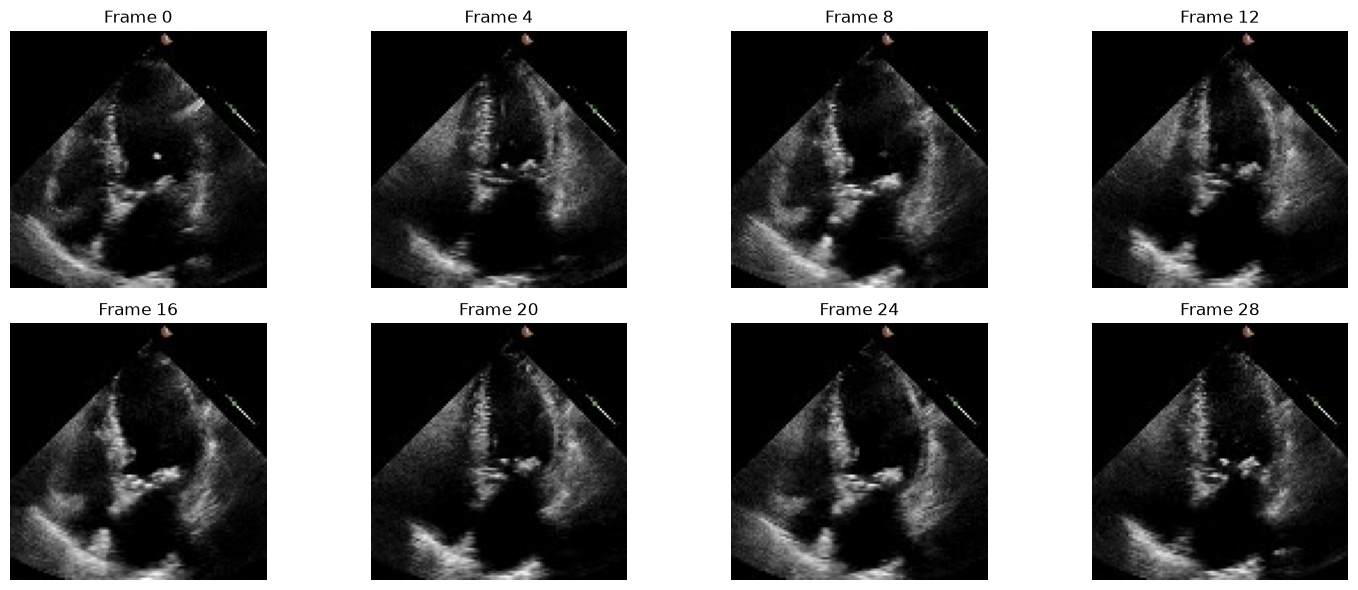

In [ ]:
# ============================================================
# Visualize Sampled Frames
# ============================================================

plt.figure(figsize=(15,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    frame_index = int(i * len(sampled) / 8)

    plt.imshow(sampled[frame_index])

    plt.title(f"Frame {frame_index}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [7]:
# ============================================================
# Resize Frames
# ============================================================

def resize_frames(frames, target_size=(112, 112)):

    resized_frames = np.array([
        cv2.resize(frame, target_size, interpolation=cv2.INTER_AREA)
        for frame in frames
    ])

    return resized_frames

In [8]:
# ============================================================
# Test Resize Function
# ============================================================

resized = resize_frames(sampled, target_size=(112, 112))

print("Before Resize :", sampled.shape)
print("After Resize  :", resized.shape)

Before Resize : (32, 112, 112, 3)
After Resize  : (32, 112, 112, 3)


In [9]:
# ============================================================
# Normalize Pixel Values
# ============================================================

def normalize_frames(frames):

    print("Input dtype :", frames.dtype)
    print("Input range :", frames.min(), "-", frames.max())

    frames = frames.astype(np.float32) / 255.0

    return frames

In [10]:
# ============================================================
# Test Normalization
# ============================================================

normalized = normalize_frames(resized)

print("Output dtype :", normalized.dtype)
print("Output range :", normalized.min(), "-", normalized.max())

Input dtype : uint8
Input range : 0 - 255
Output dtype : float32
Output range : 0.0 - 1.0


In [11]:
# ============================================================
# Save Preprocessed Frames to Disk (single video test)
# ============================================================

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "frames"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def preprocess_and_save(video_name, num_frames=32, target_size=(112, 112)):

    raw_frames = read_video(video_name)

    sampled_frames = sample_frames(raw_frames, num_frames=num_frames)
    resized_frames = resize_frames(sampled_frames, target_size=target_size)

    # Save as uint8 (no normalization at this stage)
    save_name = Path(video_name).stem + ".npy"
    save_path = PROCESSED_DIR / save_name

    np.save(save_path, resized_frames)

    return save_path

In [12]:
# ============================================================
# Test on Single Video
# ============================================================

test_path = preprocess_and_save(sample_video)

print("Saved to :", test_path)
print("File exists :", test_path.exists())
print("File size (KB) :", test_path.stat().st_size / 1024)

# Verify by loading back
loaded = np.load(test_path)
print("Loaded shape :", loaded.shape)
print("Loaded dtype :", loaded.dtype)

Saved to : d:\Projects\EchoAI-X\data\processed\frames\0X100009310A3BD7FC.npy
File exists : True
File size (KB) : 1176.125
Loaded shape : (32, 112, 112, 3)
Loaded dtype : uint8


In [13]:
# ============================================================
# Install/Import tqdm for progress tracking
# ============================================================

from tqdm import tqdm
import time

In [14]:
# ============================================================
# Time Estimate on Small Batch (20 videos)
# ============================================================

test_batch = FILE_LIST["FileName"].iloc[:20]

start_time = time.time()

for name in tqdm(test_batch, desc="Testing batch"):
    video_file = name + ".avi"
    preprocess_and_save(video_file)

elapsed = time.time() - start_time

print(f"\nTime for 20 videos : {elapsed:.2f} seconds")
print(f"Average per video   : {elapsed/20:.2f} seconds")
print(f"Estimated total time for 10,030 videos : {(elapsed/20)*10030/60:.1f} minutes")

Testing batch: 100%|██████████| 20/20 [00:01<00:00, 10.45it/s]


Time for 20 videos : 1.99 seconds
Average per video   : 0.10 seconds
Estimated total time for 10,030 videos : 16.6 minutes


In [15]:
# ============================================================
# Full Batch Preprocessing (All Videos)
# ============================================================

def preprocess_and_save_safe(video_name, num_frames=32, target_size=(112, 112)):

    save_name = Path(video_name).stem + ".npy"
    save_path = PROCESSED_DIR / save_name

    # Skip if already processed
    if save_path.exists():
        return "skipped"

    try:
        raw_frames = read_video(video_name)

        if len(raw_frames) == 0:
            return "empty"

        sampled_frames = sample_frames(raw_frames, num_frames=num_frames)
        resized_frames = resize_frames(sampled_frames, target_size=target_size)

        np.save(save_path, resized_frames)

        return "success"

    except Exception as e:
        return f"error: {str(e)}"

In [16]:
# ============================================================
# Run on Full Dataset
# ============================================================

all_video_names = FILE_LIST["FileName"] + ".avi"

results = []
failed_videos = []

for name in tqdm(all_video_names, desc="Preprocessing all videos"):

    status = preprocess_and_save_safe(name)
    results.append(status)

    if status not in ["success", "skipped"]:
        failed_videos.append((name, status))

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

from collections import Counter

status_counts = Counter(results)

print("\n===== Preprocessing Summary =====")
for status, count in status_counts.items():
    print(f"{status}: {count}")

print(f"\nTotal Failed: {len(failed_videos)}")

Preprocessing all videos: 100%|██████████| 10030/10030 [43:04<00:00,  3.88it/s]    


===== Preprocessing Summary =====
skipped: 20
success: 10010

Total Failed: 0
